=== PART 1: LOADING & SCALING IRIS DATASET ===

=== PART 2: ELBOW METHOD & K-MEANS CLUSTERING (k=3) ===


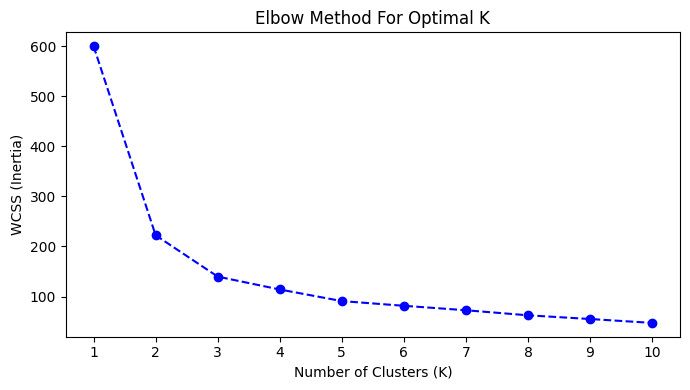


=== PART 3: APPLYING PCA (4D -> 2D) ===
Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Retained: 95.81%

=== PART 4: VISUALIZING CLUSTERS VS TRUE LABELS ===


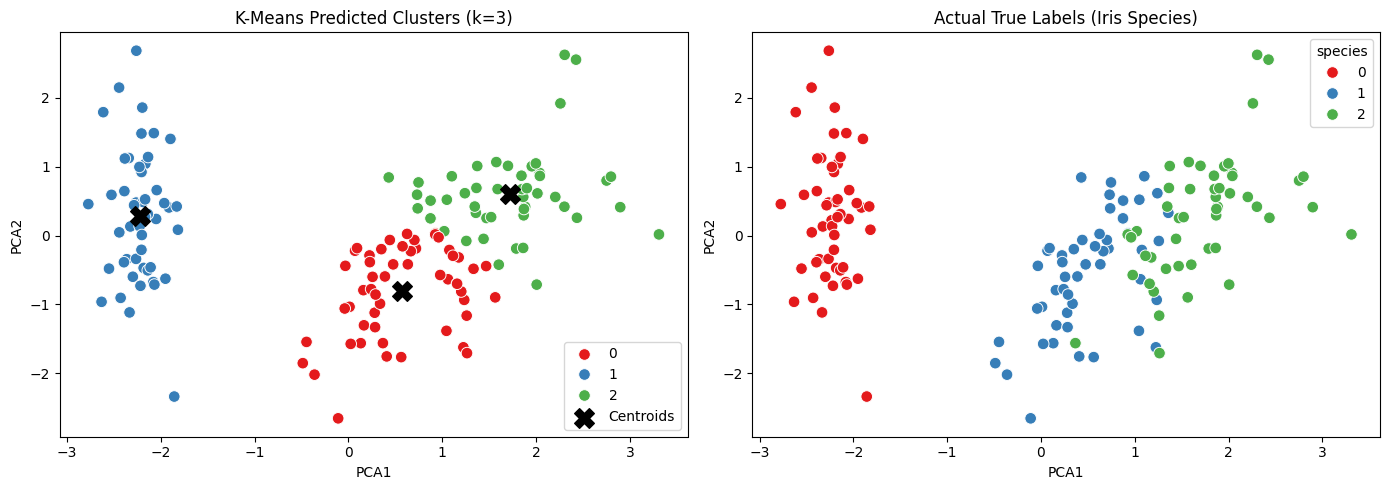


=== PART 5: SAVING & RELOADING MODEL ===
Model saved as 'kmeans_iris_model.pkl'
Model successfully reloaded using joblib!




In [2]:
# =====================================================================
# MACHINE LEARNING & AI - WEEK 3 UNSUPERVISED LEARNING & MODEL EVALUATION
# =====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ---------------------------------------------------------------------
# PART 1: DATA LOADING & PREPARATION
# ---------------------------------------------------------------------
print("=== PART 1: LOADING & SCALING IRIS DATASET ===")

# Load Iris dataset built into Scikit-Learn
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convert to DataFrame for easy viewing
df_iris = pd.DataFrame(X, columns=feature_names)
df_iris['species'] = y

# Standardize features (Crucial step before K-Means and PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ---------------------------------------------------------------------
# PART 2: ASSIGNMENT 1 & MINI PROJECT 3 - K-MEANS CLUSTERING & ELBOW METHOD
# ---------------------------------------------------------------------
print("\n=== PART 2: ELBOW METHOD & K-MEANS CLUSTERING (k=3) ===")

# 1. Elbow Method to determine optimal number of clusters (K)
wcss = []  # Within-Cluster Sum of Squares
k_values = range(1, 11)

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(7, 4))
plt.plot(k_values, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_values)
plt.tight_layout()
plt.show()

# 2. Train Final K-Means model with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_iris['cluster'] = kmeans.fit_predict(X_scaled)


# ---------------------------------------------------------------------
# PART 3: ASSIGNMENT 2 - PCA (DIMENSIONALITY REDUCTION)
# ---------------------------------------------------------------------
print("\n=== PART 3: APPLYING PCA (4D -> 2D) ===")

# Reduce dataset from 4 numerical dimensions to 2 Principal Components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Store PCA results in DataFrame
df_iris['PCA1'] = X_pca[:, 0]
df_iris['PCA2'] = X_pca[:, 1]

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Variance Retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")


# ---------------------------------------------------------------------
# PART 4: VISUALIZATION & EVALUATION (PREDICTED VS TRUE LABELS)
# ---------------------------------------------------------------------
print("\n=== PART 4: VISUALIZING CLUSTERS VS TRUE LABELS ===")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: K-Means Predicted Clusters (2D via PCA)
sns.scatterplot(
    x='PCA1', y='PCA2', hue='cluster', data=df_iris,
    palette='Set1', s=70, ax=axes[0]
)
# Plot K-Means Cluster Centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X', s=200, label='Centroids')
axes[0].set_title('K-Means Predicted Clusters (k=3)')
axes[0].legend()

# Plot 2: Actual Species / True Labels (2D via PCA)
sns.scatterplot(
    x='PCA1', y='PCA2', hue='species', data=df_iris,
    palette='Set1', s=70, ax=axes[1]
)
axes[1].set_title('Actual True Labels (Iris Species)')

plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# PART 5: MODEL SAVING & LOADING (JOBLIB)
# ---------------------------------------------------------------------
print("\n=== PART 5: SAVING & RELOADING MODEL ===")

# Save the trained K-Means model and scaler
joblib.dump(kmeans, 'kmeans_iris_model.pkl')
joblib.dump(scaler, 'scaler_iris.pkl')
print("Model saved as 'kmeans_iris_model.pkl'")

# Demonstrate reloading model
loaded_kmeans = joblib.load('kmeans_iris_model.pkl')
print("Model successfully reloaded using joblib!")

print("\n")